# 프로젝트: SentencePiece를 활용한 네이버 영화리뷰 감정 분석

**목차**
1. 라이브러리 설치 및 버전 확인
2. 데이터 로드 및 전처리
3. SentencePiece 모델 학습
4. sp_tokenize()함수 구현
6. KoNLPy 형태소 분석기 기반 모델
7. SentencePiece 기반 모델
8. 성능 비교 분석 (model_type, vocab_size 변경)
9. 결과 시각화
10. SentencePiece 어휘 분석

## 0. 라이브러리 설치 및 버전 확인

In [1]:
# 필요 패키지 설치 (최초 1회)
!pip install sentencepiece konlpy torch pandas matplotlib

In [2]:
import os, re, urllib.request

import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

import sentencepiece as spm
import pandas as pd

print('=== 라이브러리 버전 확인 ===')
print(f'torch      : {torch.__version__}')
print(f'numpy      : {np.__version__}')
print(f'matplotlib : {matplotlib.__version__}')
try:
    import konlpy
    print(f'konlpy     : {konlpy.__version__}')
except ImportError:
    print('konlpy     : 설치 필요')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\n사용 디바이스: {device}')

=== 라이브러리 버전 확인 ===
torch      : 2.7.1+cu118
numpy      : 2.2.6
matplotlib : 3.10.3
konlpy     : 0.6.0

사용 디바이스: cuda


## 1. 데이터 로드 및 전처리

In [3]:
TRAIN_URL = 'https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt'
TEST_URL  = 'https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt'

def download_if_not_exists(url, filename):
    if not os.path.exists(filename):
        print(f'다운로드 중: {filename}')
        urllib.request.urlretrieve(url, filename)
    else:
        print(f'이미 존재: {filename}')

download_if_not_exists(TRAIN_URL, 'ratings_train.txt')
download_if_not_exists(TEST_URL,  'ratings_test.txt')

train_df = pd.read_csv('ratings_train.txt', sep='\t')
test_df  = pd.read_csv('ratings_test.txt',  sep='\t')
print(f'Train: {train_df.shape}, Test: {test_df.shape}')
train_df.head()

이미 존재: ratings_train.txt
이미 존재: ratings_test.txt
Train: (150000, 3), Test: (50000, 3)


,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


In [4]:
def preprocess_text(text):
    if not isinstance(text, str):
        return ''
    text = re.sub(r'[^가-힣\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

for df in [train_df, test_df]:
    df.dropna(subset=['document', 'label'], inplace=True)
    df['document'] = df['document'].apply(preprocess_text)

train_df = train_df[train_df['document'].str.len() > 0].reset_index(drop=True)
test_df  = test_df[test_df['document'].str.len()  > 0].reset_index(drop=True)

train_corpus = train_df['document'].tolist()
test_corpus  = test_df['document'].tolist()
train_labels = train_df['label'].tolist()
test_labels  = test_df['label'].tolist()

print(f'전처리 후 Train: {len(train_corpus)}, Test: {len(test_corpus)}')
print('샘플:', train_corpus[0])

전처리 후 Train: 148385, Test: 49430
샘플: 아 더빙 진짜 짜증나네요 목소리


## 2. SentencePiece 모델 학습

- `model_type=unigram` 이 기본값입니다. `--model_type=bpe` 로 변경 가능합니다.
- 학습 결과물: `nsmc_spm.model`, `nsmc_spm.vocab`

In [5]:
TEMP_FILE    = 'nsmc_corpus.txt'
VOCAB_SIZE   = 8000
MODEL_PREFIX = 'nsmc_spm'

# 학습 코퍼스 파일 생성
with open(TEMP_FILE, 'w', encoding='utf-8') as f:
    for sentence in train_corpus:
        f.write(sentence + '\n')

# SentencePiece 학습
if not os.path.exists(f'{MODEL_PREFIX}.model'):
    spm.SentencePieceTrainer.Train(
        f'--input={TEMP_FILE} '
        f'--model_prefix={MODEL_PREFIX} '
        f'--vocab_size={VOCAB_SIZE} '
        f'--model_type=unigram '
        f'--pad_id=0 --unk_id=1 --bos_id=2 --eos_id=3'
    )
    print('unigram 모델 학습 완료')
else:
    print('기존 모델 로드')

!ls -lh nsmc_spm*

기존 모델 로드
-rw-rw-r-- 1 jovyan users 374K Apr 13 07:33 nsmc_spm.model
-rw-rw-r-- 1 jovyan users 146K Apr 13 07:33 nsmc_spm.vocab


In [6]:
# 모델 로드 및 동작 확인
sp = spm.SentencePieceProcessor()
sp.Load(f'{MODEL_PREFIX}.model')

sample = '이 영화는 정말 재미있어서 두 번이나 봤어요'
print(f'원문             : {sample}')
print(f'EncodeAsIds      : {sp.EncodeAsIds(sample)}')
print(f'EncodeAsPieces   : {sp.EncodeAsPieces(sample)}')
print(f'DecodeIds (복원) : {sp.DecodeIds(sp.EncodeAsIds(sample))}')

원문             : 이 영화는 정말 재미있어서 두 번이나 봤어요
EncodeAsIds      : [20, 110, 22, 3834, 38, 282, 421, 218, 816]
EncodeAsPieces   : ['▁이', '▁영화는', '▁정말', '▁재미있어', '서', '▁두', '▁번', '이나', '▁봤어요']
DecodeIds (복원) : 이 영화는 정말 재미있어서 두 번이나 봤어요


## 3. `sp_tokenize()` 함수 구현

| 조건 | 내용 |
|------|------|
| ① | 매개변수: 온전한 문장의 `list` |
| ② | `word_index` / `index_word` 사전 반환 |
| ③ | 패딩이 포함된 인코딩 텐서 반환 |

In [7]:
def sp_tokenize(s, corpus, model_prefix='nsmc_spm'):
    """
    SentencePiece 기반 토크나이저.

    Args:
        s            : 학습된 SentencePieceProcessor
        corpus       : 문장 리스트
        model_prefix : vocab 파일 위치 접두사

    Returns:
        tensor     : (N, max_len) 패딩 텐서
        word_index : {word: idx}
        index_word : {idx: word}
    """
    # ① 인코딩
    sequences = []
    for sentence in corpus:
        ids = s.EncodeAsIds(sentence)
        sequences.append(torch.tensor(ids, dtype=torch.long))

    # ③ 패딩
    tensor = pad_sequence(sequences, batch_first=True, padding_value=0)

    # ② vocab 사전 생성
    word_index, index_word = {}, {}
    with open(f'{model_prefix}.vocab', 'r', encoding='utf-8') as f:
        for idx, line in enumerate(f):
            word = line.split('\t')[0]
            word_index[word] = idx
            index_word[idx]  = word

    return tensor, word_index, index_word

# 동작 확인
sample_corpus = ['이 영화 정말 재미있다', '완전 별로야 돈 아깝다', '배우들 연기가 훌륭해']
t, wi, iw = sp_tokenize(sp, sample_corpus)
print(f'tensor shape : {t.shape}')
print(f'vocab size   : {len(wi)}')
print(f'인덱스 10번 단어: {iw.get(10)}')

tensor shape : torch.Size([3, 5])
vocab size   : 8000
인덱스 10번 단어: 는


## 4. 공통 유틸리티: Dataset / Model / 학습·평가 함수

In [8]:
class ReviewDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels    = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

def collate_fn(batch):
    seqs, labs = zip(*batch)
    seqs_padded = pad_sequence(seqs, batch_first=True, padding_value=0)
    labs_tensor = torch.tensor(labs, dtype=torch.long)
    return seqs_padded, labs_tensor

class TextRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256,
                 n_layers=2, n_classes=2, dropout=0.3, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.rnn = nn.LSTM(embed_dim, hidden_dim, num_layers=n_layers,
                           batch_first=True, dropout=dropout, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, n_classes)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        _, (h, _) = self.rnn(emb)
        h = torch.cat([h[-2], h[-1]], dim=-1)  # 양방향 마지막 hidden
        return self.fc(self.dropout(h))

In [9]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for seqs, labs in loader:
        seqs, labs = seqs.to(device), labs.to(device)
        optimizer.zero_grad()
        loss = criterion(model(seqs), labs)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * seqs.size(0)
        correct    += (model(seqs).argmax(1) == labs).sum().item()
        total      += seqs.size(0)
    return total_loss / total, correct / total

def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for seqs, labs in loader:
            seqs, labs = seqs.to(device), labs.to(device)
            preds = model(seqs)
            total_loss += criterion(preds, labs).item() * seqs.size(0)
            correct    += (preds.argmax(1) == labs).sum().item()
            total      += seqs.size(0)
    return total_loss / total, correct / total

def run_experiment(name, train_seqs, test_seqs, train_labels, test_labels,
                   vocab_size, n_epochs=5, batch_size=256, lr=1e-3):
    sep = '='*60
    print(f'\n{sep}\n실험: {name}\n{sep}')
    train_loader = DataLoader(ReviewDataset(train_seqs, train_labels),
                              batch_size=batch_size, shuffle=True,  collate_fn=collate_fn)
    test_loader  = DataLoader(ReviewDataset(test_seqs,  test_labels),
                              batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
    model     = TextRNN(vocab_size=vocab_size).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)
    history   = {'train_loss':[], 'train_acc':[], 'test_loss':[], 'test_acc':[]}
    for epoch in range(1, n_epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        te_loss, te_acc = eval_epoch(model, test_loader,  criterion, device)
        scheduler.step()
        for k, v in zip(['train_loss','train_acc','test_loss','test_acc'],
                         [tr_loss, tr_acc, te_loss, te_acc]):
            history[k].append(v)
        print(f'Epoch {epoch:2d} | Train Loss: {tr_loss:.4f}, Acc: {tr_acc*100:.2f}% | '
              f'Test Loss: {te_loss:.4f}, Acc: {te_acc*100:.2f}%')
    print(f'\n최종 Test Accuracy: {history["test_acc"][-1]*100:.2f}%')
    return history, history['test_acc'][-1]

## 5. KoNLPy (Okt) 형태소 분석기 기반 모델

> Okt 분석은 시간이 많이 걸리므로 `SAMPLE_N = 20000` 샘플로 실험합니다.

In [10]:
try:
    from konlpy.tag import Okt
    from collections import Counter

    okt = Okt()
    SAMPLE_N = 20000

    tr_idx = np.random.choice(len(train_corpus), min(SAMPLE_N, len(train_corpus)), replace=False)
    te_idx = np.random.choice(len(test_corpus),  min(SAMPLE_N//5, len(test_corpus)), replace=False)

    okt_tr_corp = [train_corpus[i] for i in tr_idx]
    okt_tr_labs = [train_labels[i] for i in tr_idx]
    okt_te_corp = [test_corpus[i]  for i in te_idx]
    okt_te_labs = [test_labels[i]  for i in te_idx]

    print('Okt 형태소 분석 중 (Train)...')
    okt_tr_tok = [okt.morphs(s, stem=True) for s in okt_tr_corp]

    MAX_VOCAB = 8000
    counter   = Counter(t for sent in okt_tr_tok for t in sent)
    vocab     = ['<PAD>', '<UNK>'] + [w for w, _ in counter.most_common(MAX_VOCAB - 2)]
    okt_wi    = {w: i for i, w in enumerate(vocab)}
    okt_iw    = {i: w for i, w in enumerate(vocab)}

    okt_tr_seqs = [torch.tensor([okt_wi.get(t, 1) for t in s], dtype=torch.long)
                   for s in okt_tr_tok]

    print('Okt 형태소 분석 중 (Test)...')
    okt_te_seqs = [torch.tensor([okt_wi.get(t, 1) for t in okt.morphs(s, stem=True)],
                   dtype=torch.long) for s in okt_te_corp]

    okt_history, okt_acc = run_experiment(
        name='Okt 형태소 분석기',
        train_seqs=okt_tr_seqs, test_seqs=okt_te_seqs,
        train_labels=okt_tr_labs, test_labels=okt_te_labs,
        vocab_size=len(okt_wi),
    )
except ImportError:
    print('KoNLPy 미설치. pip install konlpy 후 재실행하세요.')
    okt_history, okt_acc = None, None

Okt 형태소 분석 중 (Train)...
Okt 형태소 분석 중 (Test)...

실험: Okt 형태소 분석기
Epoch  1 | Train Loss: 0.6084, Acc: 66.97% | Test Loss: 0.5213, Acc: 74.00%
Epoch  2 | Train Loss: 0.5107, Acc: 75.35% | Test Loss: 0.4662, Acc: 76.92%
Epoch  3 | Train Loss: 0.4465, Acc: 79.22% | Test Loss: 0.4351, Acc: 79.47%
Epoch  4 | Train Loss: 0.4154, Acc: 81.30% | Test Loss: 0.4158, Acc: 80.45%
Epoch  5 | Train Loss: 0.3832, Acc: 82.64% | Test Loss: 0.4145, Acc: 81.27%

최종 Test Accuracy: 81.27%


## 6. SentencePiece 기반 모델 (unigram, vocab=8000)

In [11]:
def sp_encode_corpus(sp_model, corpus):
    return [torch.tensor(sp_model.EncodeAsIds(s), dtype=torch.long) for s in corpus]

sp_tr_seqs = sp_encode_corpus(sp, train_corpus)
sp_te_seqs = sp_encode_corpus(sp, test_corpus)

sp_unigram_history, sp_unigram_acc = run_experiment(
    name='SentencePiece (unigram, vocab=8000)',
    train_seqs=sp_tr_seqs, test_seqs=sp_te_seqs,
    train_labels=train_labels, test_labels=test_labels,
    vocab_size=VOCAB_SIZE,
)


실험: SentencePiece (unigram, vocab=8000)
Epoch  1 | Train Loss: 0.5470, Acc: 71.84% | Test Loss: 0.4097, Acc: 81.01%
Epoch  2 | Train Loss: 0.4035, Acc: 81.71% | Test Loss: 0.3610, Acc: 84.00%
Epoch  3 | Train Loss: 0.3533, Acc: 84.40% | Test Loss: 0.3444, Acc: 84.79%
Epoch  4 | Train Loss: 0.3344, Acc: 85.36% | Test Loss: 0.3441, Acc: 85.04%
Epoch  5 | Train Loss: 0.3121, Acc: 86.44% | Test Loss: 0.3398, Acc: 85.39%

최종 Test Accuracy: 85.39%


## 7. 다양한 SentencePiece 설정 비교

| model_type | vocab_size |
|-----------|----------|
| bpe       | 4,000    |
| bpe       | 8,000    |
| unigram   | 4,000    |
| unigram   | 16,000   |

In [12]:
EXPERIMENTS = [
    {'model_type': 'bpe',     'vocab_size': 4000},
    {'model_type': 'bpe',     'vocab_size': 8000},
    {'model_type': 'unigram', 'vocab_size': 4000},
    {'model_type': 'unigram', 'vocab_size': 16000},
]

all_results = {'SP unigram\nvocab=8000': sp_unigram_history}
if okt_history:
    all_results['Okt\n형태소'] = okt_history

for cfg in EXPERIMENTS:
    mt, vs = cfg['model_type'], cfg['vocab_size']
    pfx    = f'nsmc_spm_{mt}_{vs}'
    label  = f'SP {mt}\nvocab={vs}'

    if not os.path.exists(f'{pfx}.model'):
        spm.SentencePieceTrainer.Train(
            f'--input={TEMP_FILE} --model_prefix={pfx} '
            f'--vocab_size={vs} --model_type={mt} '
            f'--pad_id=0 --unk_id=1 --bos_id=2 --eos_id=3'
        )

    sp_cfg = spm.SentencePieceProcessor()
    sp_cfg.Load(f'{pfx}.model')

    tr_s = sp_encode_corpus(sp_cfg, train_corpus)
    te_s = sp_encode_corpus(sp_cfg, test_corpus)

    hist, _ = run_experiment(
        name=f'SP {mt} vocab={vs}',
        train_seqs=tr_s, test_seqs=te_s,
        train_labels=train_labels, test_labels=test_labels,
        vocab_size=vs,
    )
    all_results[label] = hist

sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=nsmc_corpus.txt --model_prefix=nsmc_spm_bpe_4000 --vocab_size=4000 --model_type=bpe --pad_id=0 --unk_id=1 --bos_id=2 --eos_id=3
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: nsmc_corpus.txt
  input_format: 
  model_prefix: nsmc_spm_bpe_4000
  model_type: BPE
  vocab_size: 4000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1


실험: SP bpe vocab=4000
Epoch  1 | Train Loss: 0.5240, Acc: 73.75% | Test Loss: 0.4036, Acc: 81.64%
Epoch  2 | Train Loss: 0.4028, Acc: 81.85% | Test Loss: 0.3634, Acc: 83.86%
Epoch  3 | Train Loss: 0.3555, Acc: 84.10% | Test Loss: 0.3535, Acc: 84.61%
Epoch  4 | Train Loss: 0.3397, Acc: 85.00% | Test Loss: 0.3493, Acc: 84.87%
Epoch  5 | Train Loss: 0.3178, Acc: 86.13% | Test Loss: 0.3395, Acc: 85.46%

최종 Test Accuracy: 85.46%


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=nsmc_corpus.txt --model_prefix=nsmc_spm_bpe_8000 --vocab_size=8000 --model_type=bpe --pad_id=0 --unk_id=1 --bos_id=2 --eos_id=3
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: nsmc_corpus.txt
  input_format: 
  model_prefix: nsmc_spm_bpe_8000
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1


실험: SP bpe vocab=8000
Epoch  1 | Train Loss: 0.5382, Acc: 72.62% | Test Loss: 0.4179, Acc: 80.69%
Epoch  2 | Train Loss: 0.4056, Acc: 81.73% | Test Loss: 0.3643, Acc: 83.76%
Epoch  3 | Train Loss: 0.3539, Acc: 84.34% | Test Loss: 0.3493, Acc: 84.73%
Epoch  4 | Train Loss: 0.3352, Acc: 85.21% | Test Loss: 0.3415, Acc: 85.02%
Epoch  5 | Train Loss: 0.3150, Acc: 86.26% | Test Loss: 0.3396, Acc: 85.37%

최종 Test Accuracy: 85.37%


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=nsmc_corpus.txt --model_prefix=nsmc_spm_unigram_4000 --vocab_size=4000 --model_type=unigram --pad_id=0 --unk_id=1 --bos_id=2 --eos_id=3
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: nsmc_corpus.txt
  input_format: 
  model_prefix: nsmc_spm_unigram_4000
  model_type: UNIGRAM
  vocab_size: 4000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  har


실험: SP unigram vocab=4000
Epoch  1 | Train Loss: 0.5235, Acc: 73.80% | Test Loss: 0.4065, Acc: 81.38%
Epoch  2 | Train Loss: 0.3990, Acc: 82.15% | Test Loss: 0.3653, Acc: 83.45%
Epoch  3 | Train Loss: 0.3544, Acc: 84.28% | Test Loss: 0.3477, Acc: 84.67%
Epoch  4 | Train Loss: 0.3362, Acc: 85.21% | Test Loss: 0.3411, Acc: 84.90%
Epoch  5 | Train Loss: 0.3163, Acc: 86.18% | Test Loss: 0.3361, Acc: 85.44%

최종 Test Accuracy: 85.44%


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=nsmc_corpus.txt --model_prefix=nsmc_spm_unigram_16000 --vocab_size=16000 --model_type=unigram --pad_id=0 --unk_id=1 --bos_id=2 --eos_id=3
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: nsmc_corpus.txt
  input_format: 
  model_prefix: nsmc_spm_unigram_16000
  model_type: UNIGRAM
  vocab_size: 16000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
 


실험: SP unigram vocab=16000
Epoch  1 | Train Loss: 0.5550, Acc: 71.31% | Test Loss: 0.4247, Acc: 80.15%
Epoch  2 | Train Loss: 0.4125, Acc: 81.27% | Test Loss: 0.3714, Acc: 83.20%
Epoch  3 | Train Loss: 0.3552, Acc: 84.29% | Test Loss: 0.3563, Acc: 84.12%
Epoch  4 | Train Loss: 0.3345, Acc: 85.39% | Test Loss: 0.3446, Acc: 84.81%
Epoch  5 | Train Loss: 0.3129, Acc: 86.47% | Test Loss: 0.3475, Acc: 84.88%

최종 Test Accuracy: 84.88%


## 8. 결과 시각화

/tmp/ipykernel_1730/2639552421.py:28: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1730/2639552421.py:28: UserWarning: Glyph 53468 (\N{HANGUL SYLLABLE TAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1730/2639552421.py:28: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1730/2639552421.py:28: UserWarning: Glyph 53664 (\N{HANGUL SYLLABLE TO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1730/2639552421.py:28: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1730/2639552421.py:28: UserWarning: Glyph 45208 (\N{HANGUL SYLLABLE NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1730/2639552421.py:28: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_lay

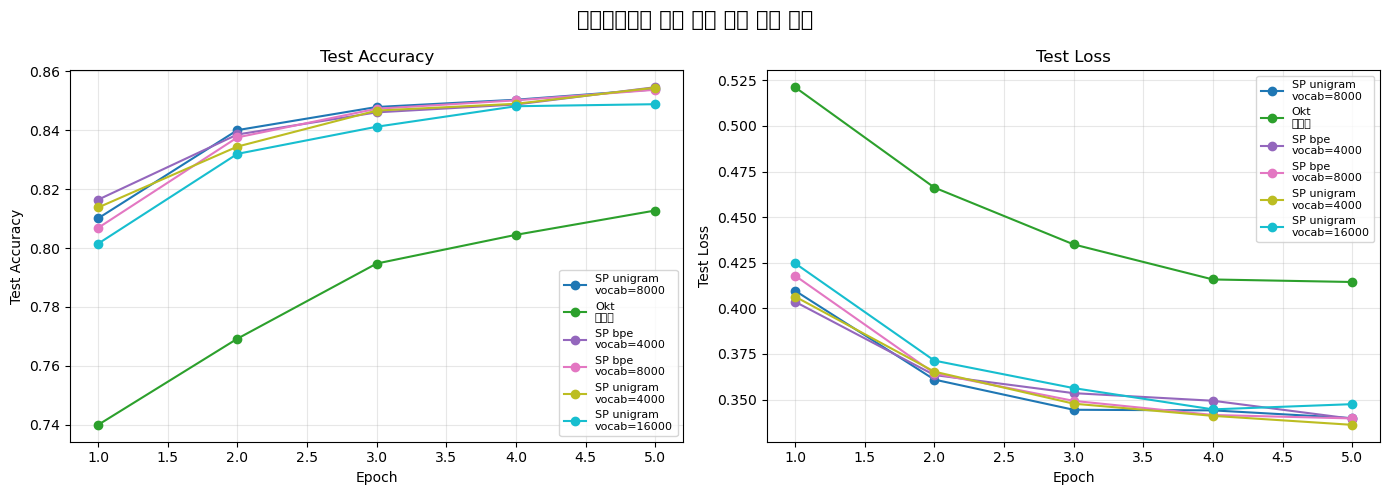

그래프 저장: tokenizer_comparison.png


In [13]:
# 한글 폰트 설정
plt.rcParams['axes.unicode_minus'] = False
try:
    font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
    font_prop = fm.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = font_prop.get_name()
except Exception:
    pass

n_exp  = len(all_results)
colors = plt.cm.tab10(np.linspace(0, 1, n_exp))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('토크나이저별 감정 분석 모델 성능 비교', fontsize=15, fontweight='bold')

for ax, metric, ylabel in zip(axes,
                               ['test_acc', 'test_loss'],
                               ['Test Accuracy', 'Test Loss']):
    for (label, hist), color in zip(all_results.items(), colors):
        epochs = range(1, len(hist[metric]) + 1)
        ax.plot(epochs, hist[metric], marker='o', label=label.replace('\\n',' '), color=color)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('tokenizer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('그래프 저장: tokenizer_comparison.png')

In [15]:
sep = '='*55
print(sep)
print(f'{"실험명":<35} {"최종 Test Acc":>15}')
print(sep)
for label, hist in all_results.items():
    clean = label.replace('\n', ' ')
    acc   = hist['test_acc'][-1] * 100
    mark  = ' ✓' if acc >= 80 else ''
    print(f'{clean:<35} {acc:>13.2f}%{mark}')
print(sep)
print('✓ = 80% 이상 달성')

실험명                                     최종 Test Acc
SP unigram vocab=8000                       85.39% ✓
Okt 형태소                                     81.27% ✓
SP bpe vocab=4000                           85.46% ✓
SP bpe vocab=8000                           85.37% ✓
SP unigram vocab=4000                       85.44% ✓
SP unigram vocab=16000                      84.88% ✓
✓ = 80% 이상 달성


## 9. SentencePiece 어휘 분석 

학습된 vocab 파일을 열어 실제 토큰들을 살펴봅니다.

In [16]:
with open(f'{MODEL_PREFIX}.vocab', 'r', encoding='utf-8') as f:
    vocab_lines = f.readlines()

print(f'총 어휘 수: {len(vocab_lines)}')
print('\n처음 20개 토큰:')
for i, line in enumerate(vocab_lines[:20]):
    parts = line.strip().split('\t')
    print(f'  [{i:4d}] {parts[0]:15s}  score={parts[1] if len(parts)>1 else "N/A"}')

총 어휘 수: 8000

처음 20개 토큰:
  [   0] <pad>            score=0
  [   1] <unk>            score=0
  [   2] <s>              score=0
  [   3] </s>             score=0
  [   4] ▁                score=-3.24513
  [   5] 이                score=-4.2527
  [   6] ▁영화              score=-4.38291
  [   7] 의                score=-4.50094
  [   8] 도                score=-4.56588
  [   9] 가                score=-4.59866
  [  10] 는                score=-4.60035
  [  11] 을                score=-4.79126
  [  12] 에                score=-4.88661
  [  13] 고                score=-4.89055
  [  14] 은                score=-5.00568
  [  15] 다                score=-5.0233
  [  16] 지                score=-5.06949
  [  17] 를                score=-5.31099
  [  18] 한                score=-5.32484
  [  19] ▁너무              score=-5.35059


In [17]:
samples = [
    '이 영화 정말 재미없다 돈 아깝다',
    '배우들의 연기가 너무 훌륭해서 감동받았어요',
    '스토리가 엉망이고 시간 낭비였습니다',
]
print('샘플 문장 토크나이징:')
for sent in samples:
    pieces = sp.EncodeAsPieces(sent)
    ids    = sp.EncodeAsIds(sent)
    print(f'\n원문  : {sent}')
    print(f'조각  : {pieces}')
    print(f'인덱스: {ids}')

샘플 문장 토크나이징:

원문  : 이 영화 정말 재미없다 돈 아깝다
조각  : ['▁이', '▁영화', '▁정말', '▁재미없다', '▁돈', '▁아깝다']
인덱스: [20, 6, 22, 372, 263, 196]

원문  : 배우들의 연기가 너무 훌륭해서 감동받았어요
조각  : ['▁배우들의', '▁연기가', '▁너무', '▁훌륭', '해서', '▁감동받', '았어요']
인덱스: [636, 453, 19, 1842, 115, 4699, 4831]

원문  : 스토리가 엉망이고 시간 낭비였습니다
조각  : ['▁스토리가', '▁엉망이', '고', '▁시간', '▁낭비', '였습니다']
인덱스: [477, 4518, 13, 148, 2130, 1647]
